In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('/Users/navaldhandha/Library/CloudStorage/GoogleDrive-dhandhanaval@gmail.com/My Drive/Invoice_inventory_intelligence/data/inventory.db')
tables = pd.read_sql_query('select name from sqlite_master where type = "table"',conn)
for table in tables['name']:
    print(table)
    df = pd.read_sql_query(f'select * from {table} limit 5',conn)
    display(df)

purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [9]:
purchase_agg_df = pd.read_sql_query('''
select 
    PONumber,
    count(distinct Brand) as no_brands,
    sum(Quantity) as total_quantity,
    sum(Dollars) as total_amount,
    avg(julianday(ReceivingDate)-julianday(PODate)) as avg_receiving_delay,
    avg(julianday(InvoiceDate) - julianday(ReceivingDate)) as avg_invoice_raise_delay
from 
    purchases
group by PONumber
''',conn)

In [11]:
purchase_agg_df.shape

(5543, 6)

In [14]:
df = pd.read_sql_query('''
with purchase_agg as (
select 
    PONumber,
    count(distinct Brand) as no_brands,
    sum(Quantity) as total_quantity,
    sum(Dollars) as total_amount,
    avg(julianday(ReceivingDate)-julianday(PODate)) as avg_receiving_delay,
    avg(julianday(InvoiceDate) - julianday(ReceivingDate)) as avg_invoice_raise_delay
from 
    purchases
group by PONumber
)
select
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_amount,
    vi.Freight,
    julianday(vi.InvoiceDate) - julianday(vi.PODate) as invoice_to_podate,
    julianday(vi.PayDate) - julianday(vi.InvoiceDate) as days_to_pay,
    p.no_brands,
    p.total_quantity,
    p.total_amount,
    p.avg_receiving_delay,
    p.avg_invoice_raise_delay
from 
    vendor_invoice vi
left join
    purchase_agg p
on vi.PONumber = p.PONumber    
''',conn)

In [15]:
df

,PONumber,invoice_quantity,invoice_amount,Freight,invoice_to_podate,days_to_pay,no_brands,total_quantity,total_amount,avg_receiving_delay,avg_invoice_raise_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000,2.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333,5.666667
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000,7.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130,10.385870
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809,5.247191
...,...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795,8.128205
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500,11.949500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000,8.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541,7.954459


In [17]:
df.isnull().sum()

PONumber                   0
invoice_quantity           0
invoice_amount             0
Freight                    0
invoice_to_podate          0
days_to_pay                0
no_brands                  0
total_quantity             0
total_amount               0
avg_receiving_delay        0
avg_invoice_raise_delay    0
dtype: int64

In [19]:
def create_credit_risk_label(row):
    
    if abs(row['invoice_amount'] - row['total_amount']) > 5:
        return 1

    if row['avg_receiving_delay'] > 10:
        return 1

    return 0

df['flag_invoice'] = df.apply(create_credit_risk_label, axis = 1)
df['flag_invoice'].value_counts()    

0    3693
1    1850
Name: flag_invoice, dtype: int64

<Axes: >

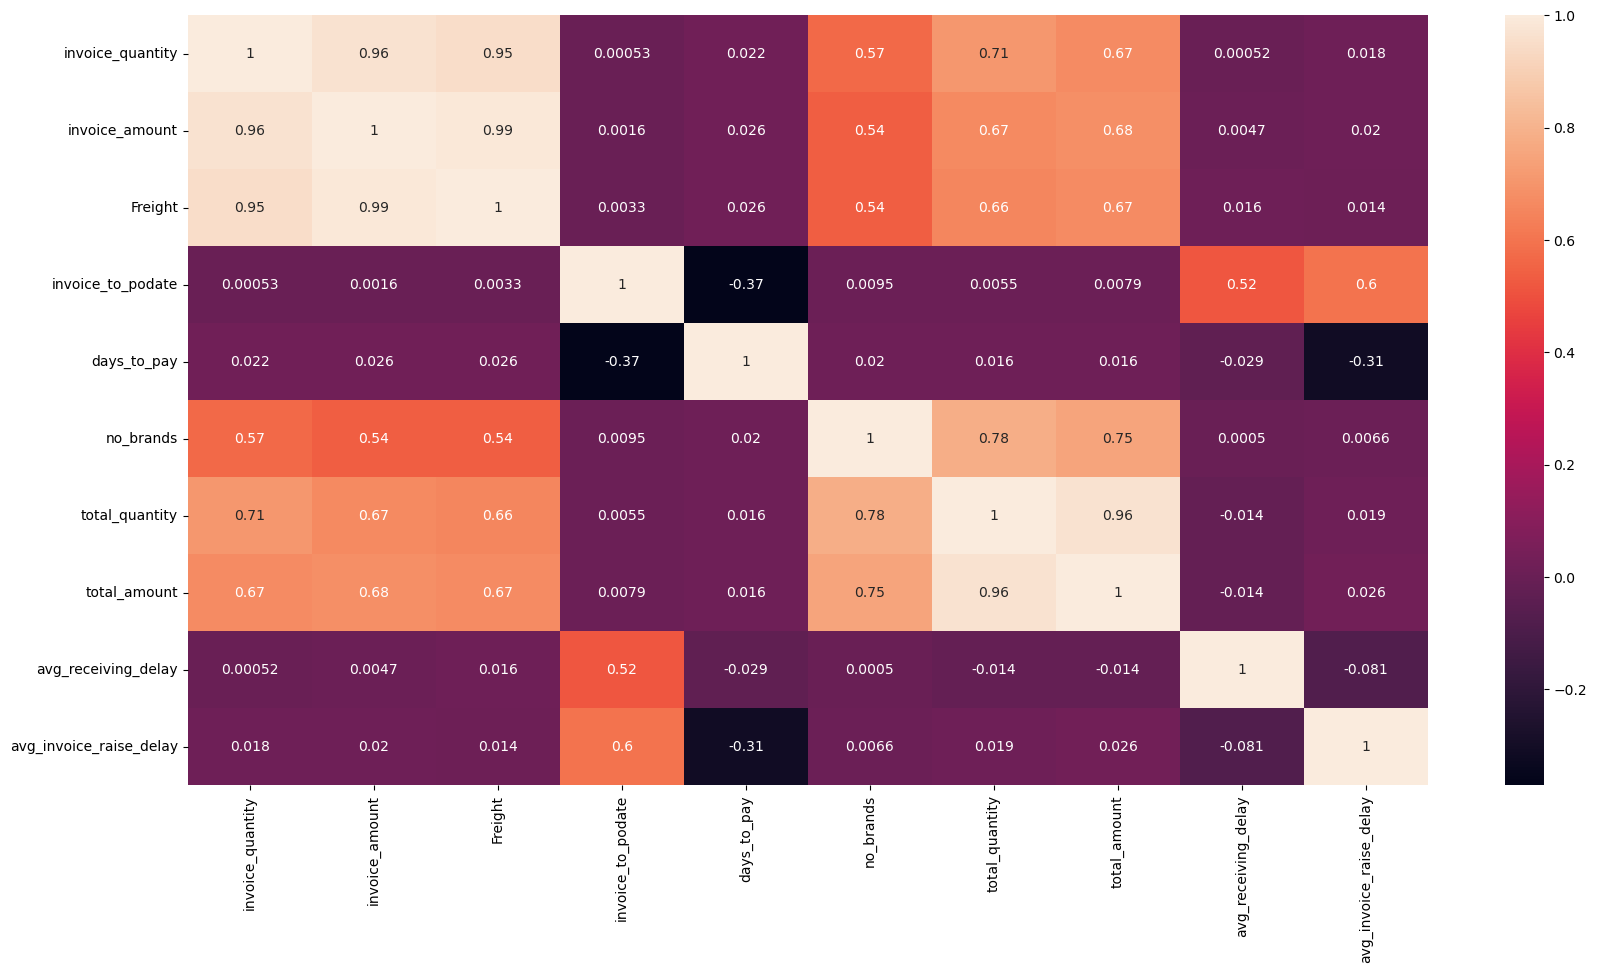

In [25]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(),annot = True)

In [40]:
flagged = df[df['flag_invoice']==1]
non_flagged = df[df['flag_invoice']==0]
metrics = ['invoice_quantity','invoice_amount','Freight','invoice_to_podate','days_to_pay','no_brands','total_quantity','total_amount','avg_receiving_delay','avg_invoice_raise_delay']
significant_features = []
nonsignificant_features = []
results = []

In [41]:
from scipy.stats import ttest_ind
for metric in metrics:
    flagged_mean = flagged[metric].mean()
    non_flagged_mean = non_flagged[metric].mean()
    
    t_stat,p_value = ttest_ind(
        flagged[metric],
        non_flagged[metric],
        equal_var = False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric':metric,
            'flagged_mean':flagged_mean.round(2),
            'non_flagged_mean':non_flagged_mean.round(2),
            'p_value':p_value.round(3)
        })
    else:
        nonsignificant_features.append(metric)

In [42]:
significant_features

['invoice_quantity',
 'invoice_amount',
 'Freight',
 'invoice_to_podate',
 'total_quantity',
 'total_amount',
 'avg_receiving_delay']

In [32]:
nonsignificant_features

['days_to_pay', 'no_brands', 'avg_invoice_raise_delay']

In [43]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'non_flagged_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_amount',
  'flagged_mean': 65600.61,
  'non_flagged_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'non_flagged_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'invoice_to_podate',
  'flagged_mean': 17.23,
  'non_flagged_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_quantity',
  'flagged_mean': 6728.28,
  'non_flagged_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_amount',
  'flagged_mean': 65600.61,
  'non_flagged_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'non_flagged_mean': 7.27,
  'p_value': 0.0}]

In [44]:
X = df[significant_features]
y = df['flag_invoice']

In [47]:
X.describe().round()

,invoice_quantity,invoice_amount,Freight,invoice_to_podate,total_quantity,total_amount,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,141660.0,1660436.0,13.0


In [48]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)


In [56]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [57]:
m1 = LogisticRegression(random_state = 42)
m1.fit(X_train_scaled,y_train)

m2 = DecisionTreeClassifier(random_state = 42)
m2.fit(X_train_scaled,y_train)

m3 = RandomForestClassifier(random_state = 42)
m3.fit(X_train_scaled,y_train)


RandomForestClassifier(random_state=42)

In [54]:
from sklearn.metrics import accuracy_score, classification_report
def model_evaluation(model,X_test,y_test,model_name):
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test,y_pred)
    
    print(f'{model_name}:')
    print(f'accuracy:{accuracy:.2f}')
    print('Classification report')
    print(classification_report(y_test,y_pred))

In [58]:
model_evaluation(m1,X_test_scaled,y_test,'Logistic Regresison')
model_evaluation(m2,X_test_scaled,y_test,'Decision Tree Classifier')
model_evaluation(m3,X_test_scaled,y_test,'Random Forest Classifier')

Logistic Regresison:
accuracy:0.75
Classification report
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       725
           1       0.81      0.37      0.50       384

    accuracy                           0.75      1109
   macro avg       0.77      0.66      0.67      1109
weighted avg       0.76      0.75      0.72      1109

Decision Tree Classifier:
accuracy:0.93
Classification report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       725
           1       0.91      0.87      0.89       384

    accuracy                           0.93      1109
   macro avg       0.92      0.91      0.92      1109
weighted avg       0.92      0.93      0.92      1109

Random Forest Classifier:
accuracy:0.95
Classification report
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       725
           1       1.00      0.86      0.92       384

 

In [62]:
m3.feature_importances_

array([0.10623606, 0.10328355, 0.10185132, 0.0258147 , 0.15347135,
       0.20475054, 0.30459248])

In [68]:
param_grid = {
    'n_estimators': [100,200,300],
    'max_depth': [None,4,5,6],
    'min_samples_split': [2,3,5],
    'min_samples_leaf': [1,2,5],
    'criterion':['gini','entropy']
}

In [69]:
from sklearn.metrics import make_scorer,f1_score
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(
    random_state = 42,
    n_jobs = -1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = scorer,
    cv = 5,
    verbose = 2,
    n_jobs = -1
)

grid_search.fit(X_train_scaled,y_train)
model_evaluation(grid_search,X_test_scaled,y_test,'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest Classifier:
accuracy:0.95
Classification report
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       725
           1       1.00      0.86      0.92       384

    accuracy                           0.95      1109
   macro avg       0.96      0.93      0.94      1109
weighted avg       0.95      0.95      0.95      1109



In [70]:
from sklearn.metrics import confusion_matrix

In [73]:
confusion_matrix(grid_search.predict(X_test_scaled),y_test)

array([[725,  55],
       [  0, 329]])

In [74]:
confusion_matrix(m3.predict(X_test_scaled),y_test)

array([[725,  55],
       [  0, 329]])

In [75]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 200}